# Confirmation Bias Project
## Preparing data for group level analyses
#### __Experiment 1:__ 

3 exactly similar sequences with same mean DV. 

In [1]:
exp_name = '3reps'

##### Import important functions and libraries

In [3]:
%matplotlib qt
%matplotlib inline

In [2]:
import os, glob
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy
import scipy.stats as stats
from scipy import signal
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
import pingouin as pg
from statsmodels.stats.multicomp import (pairwise_tukeyhsd, MultiComparison)
from matplotlib.lines import Line2D
import statsmodels as sms
#import ptitprince as pt
pd.options.display.max_columns = None # display all the columns in pandas dataframe


##### Important functions

In [3]:
def log_reg_fit(x, f): # this function was used to calculate the log linear regression between two vectors
    reg = smf.glm(formula = f, data = x, family=sm.families.Binomial()).fit()
    params = reg.params
    PSE = - reg.params.Intercept/reg.params[1]
    # concatenating parameters
    out = pd.DataFrame({'intercept':[params[0]] , 'weight':[params[1]],'PSE': PSE})
    return out #intercept + weight

def cartesian(arrays, out=None):
    """
    Examples
    --------
    >>> cartesian(([1, 2, 3], [4, 5], [6, 7]))
    """

    arrays = [np.asarray(x) for x in arrays]
    dtype = arrays[0].dtype

    n = np.prod([x.size for x in arrays])
    if out is None:
        out = np.zeros([n, len(arrays)], dtype=dtype)

    #m = n / arrays[0].size
    m = int(n / arrays[0].size) 
    out[:,0] = np.repeat(arrays[0], m)
    if arrays[1:]:
        cartesian(arrays[1:], out=out[0:m, 1:])
        for j in range(1, arrays[0].size):
        #for j in xrange(1, arrays[0].size):
            out[j*m:(j+1)*m, 1:] = out[0:m, 1:]
    return out


### Data & variables

In [6]:
import sys
import pickle

# A lightweight object to hold your PsychoPy data without any graphical baggage
class DummyPsychoPyObject:
    def __init__(self, *args, **kwargs):
        pass
        
    def __setstate__(self, state):
        if isinstance(state, dict):
            self.__dict__.update(state)
        elif isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], dict):
            self.__dict__.update(state[1])
            
    # Allow dictionary-like access since your code uses block['trial_orientations']
    def __getitem__(self, item):
        return self.__dict__[item]
        
    def __contains__(self, item):
        return item in self.__dict__
        
    def __getattr__(self, name):
        if name in self.__dict__:
            return self.__dict__[name]
        return None

# The custom Unpickler that intercepts PsychoPy classes
class SafeUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith('psychopy') or module.startswith('pyglet'):
            return DummyPsychoPyObject
        return super().find_class(module, name)


In [ ]:
dat['subjInfo']['gender (M/F)']

'M'

In [35]:
# CAUTION !! 
# Change the current path to the folder where you stored the experimental results 

results_path = '/Users/alex/Library/CloudStorage/OneDrive-UniversitatdeBarcelona/PROJECTS/Condcision/Behav_data/Behavioral/condcision3reps_same'
#results_path = '/home/freeman/Insync/alexisperez@ub.edu/OneDrive Biz/PROJECTS/Condcision/Behav_data/Behavioral/condcision3reps_same'

os.chdir(results_path) # change the current working directory to the results path 

all_df = pd.DataFrame([]) # concatenate all behav subject data together
ddata = pd.DataFrame([]) # concatenate here behav data + dv + orientations

# Initialize a list to hold the demographic info for each subject
subj_info_list = []

nsubj = 0 # initialize subjects counter

for file in sorted(glob.glob("*.psydat")): 
    subjdata = pd.DataFrame([]) # initialize individual subject data variable container
    pfile =  open(os.path.join(results_path, file),"rb")
    nsubj = nsubj + 1
    
    dat = SafeUnpickler(pfile).load()
    
    for block in dat['main_exp']['Exp_blocks']:
        dvdata = pd.DataFrame(signal.sawtooth(4 * (block['trial_orientations']), 0.5),columns=['d1','d2','d3','d4','d5','d6'])
        ddata = pd.concat([block['data'], dvdata, block['trial_orientations']], axis = 1)
        subjdata = pd.concat([subjdata, ddata], axis = 0)
    
    subjdata.insert(0, 'npar', nsubj)
    all_df = pd.concat([all_df, subjdata], axis = 0) #concatenate each new subject
    
    # Safely extract subject info and append to our list
    # We use .get() in case a key is missing for some participants
    subj_info = {
        'npar': nsubj,
        'gender': dat['subjInfo'].get('gender (M/F)', None),
        'age': dat['subjInfo'].get('age', None)
    }
    subj_info_list.append(subj_info)

# Create the new dataframe from the list after the loop finishes
subj_info_df = pd.DataFrame(subj_info_list)

# You can view the new dataframe like this:
display(subj_info_df.head())

all_df.head(10)


/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18576/1154981697.py:22: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dat = SafeUnpickler(pfile).load()
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18576/1154981697.py:22: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dat = SafeUnpickler(pfile).load()
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18576/1154981697.py:22: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dat = SafeUnpickler(pfile).load()
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18576/1154981697.py:22: VisibleD

,npar,gender,age
0,1,F,19
1,2,F,20
2,3,F,20
3,4,F,18
4,5,F,19


,npar,subj,nblock,ntrial,nrep,cond,DV,resp,r_map,correct,RT,d1,d2,d3,d4,d5,d6,o1,o2,o3,o4,o5,o6
0,1,p02,0,0,0,-1,-0.38,m,0,-1,2.836,-0.443358,-0.174941,-0.977600,-0.653679,0.748394,-0.845183,2.923,0.324,1.562,0.136,2.455,1.510
1,1,p02,0,0,1,-1,-0.38,m,0,-1,0.888,-0.443358,-0.174941,-0.977600,-0.653679,0.748394,-0.845183,2.923,0.324,1.562,0.136,2.455,1.510
2,1,p02,0,0,2,-1,-0.38,z,45,-1,1.236,-0.443358,-0.174941,-0.977600,-0.653679,0.748394,-0.845183,2.923,0.324,1.562,0.136,2.455,1.510
3,1,p02,0,1,0,-1,-0.48,m,45,1,0.834,-0.929736,0.255933,-0.458119,-0.886446,-0.203989,-0.589498,3.114,2.064,1.358,3.097,2.829,1.732
4,1,p02,0,1,1,-1,-0.48,z,0,1,1.042,-0.929736,0.255933,-0.458119,-0.886446,-0.203989,-0.589498,3.114,2.064,1.358,3.097,2.829,1.732
5,1,p02,0,1,2,-1,-0.48,m,45,1,0.701,-0.929736,0.255933,-0.458119,-0.886446,-0.203989,-0.589498,3.114,2.064,1.358,3.097,2.829,1.732
6,1,p02,0,2,0,1,0.38,z,45,1,0.713,0.086828,0.189206,0.501385,0.483560,0.626681,0.491718,1.144,0.467,2.552,2.559,0.932,0.985
7,1,p02,0,2,1,1,0.38,z,45,1,1.103,0.086828,0.189206,0.501385,0.483560,0.626681,0.491718,1.144,0.467,2.552,2.559,0.932,0.985
8,1,p02,0,2,2,1,0.38,z,45,1,0.624,0.086828,0.189206,0.501385,0.483560,0.626681,0.491718,1.144,0.467,2.552,2.559,0.932,0.985
9,1,p02,0,3,0,1,0.38,z,0,-1,0.655,0.789138,-0.088360,-0.037950,0.500395,0.920564,0.244191,2.439,0.358,1.193,2.160,2.325,2.653


In [36]:
np.shape(subj_info_df)

(29, 3)

In [38]:
df = all_df.copy() # copy tge variable

# relabeling some variables
df['cond'] = all_df['cond'].replace([-1], 0)
df['correct'] = all_df['correct'].replace([-1], 0)
df.insert(5, 'cond-1', 0)    # 0 = previous Diag / 1 = previous Card
df['cond-1'] = df['cond'].shift(1, fill_value  = 0)

# Inserting deci variable
df.insert(8, 'deci', 0)
crit1 = (df['cond']  > 0) & (df['correct'] == 1);    # 0 = diagonal       
crit2 = (df['cond']  < 0) & (df['correct'] == 0);            
crit3 = (df['cond'] == 0) & (df['correct'] == 0);
df.loc[crit1 | crit2 | crit3, 'deci'] = 1 

# Inserting the new necessary columns coding trials properly
df.insert(7, 'deci-3', 0)    # 0 = 2 previous Diag / 1 = previous Card
df.insert(8, 'deci-2', 0)    # 0 = previous Diag / 1 = previous Card
df.insert(9, 'deci-1', 0)    # 0 = previous Diag / 1 = previous Card
df.insert(14, 'corr-1', 0) # O = incorrect / 1 = correct
df.insert(7, 'rDV', 0) # rDV (real Decision Variable)

# Recoding variables
df['deci-1'] = df['deci'].shift(1, fill_value  = 0) # deci in trial n-1
df['deci-2'] = df['deci-1'].shift(1, fill_value  = 0) # deci in trial n-2
df['deci-3'] = df['deci-2'].shift(1, fill_value  = 0) # deci in trial n-2
df['corr-1'] = df['correct'].shift(1, fill_value  = 0) # correct in trial n-1

df['rDV'] = np.mean(df.iloc[:,18:24], axis = 1) # average DV
df.head(50)


df.reset_index(drop=True, inplace=True)

## df['nrep'] = df['nrep'].astype('category')
df['npar'] = df['npar'].astype('category')
df['nblock'] = df['nblock'].astype('category')
df['cond-1'] = df['cond-1'].astype('category')
df['deci-1'] = df['deci-1'].astype('category')
df['deci-2'] = df['deci-2'].astype('category')
df['deci-3'] = df['deci-3'].astype('category')
df.insert(0, 'exp_ID', exp_name) # rDV (real Decision Variable)

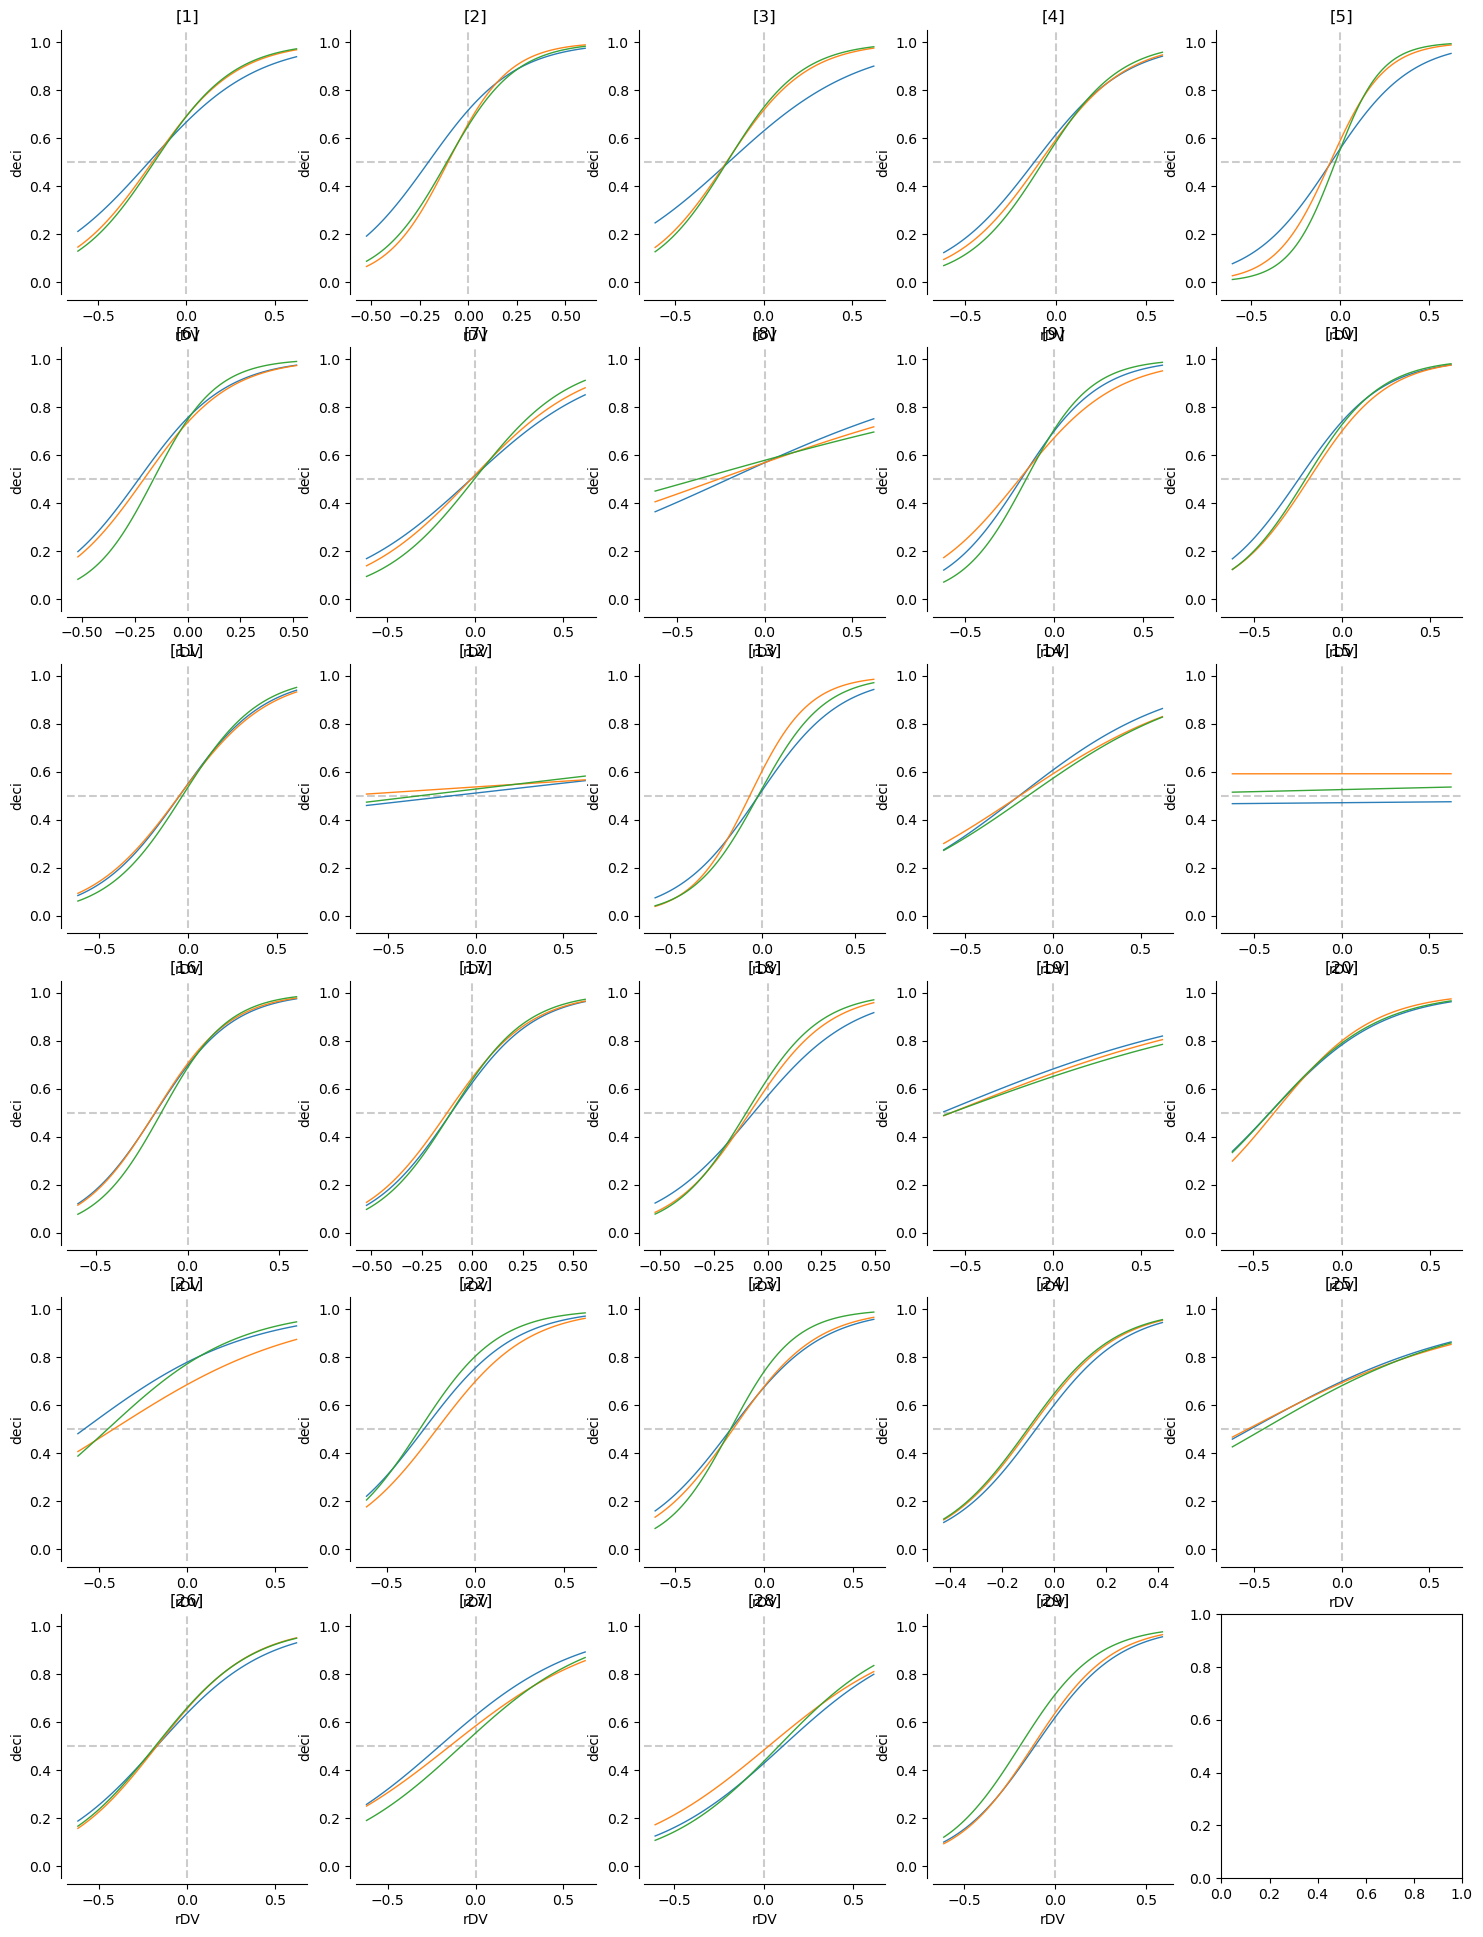

In [22]:
%%capture --no-display

nprows = 6 
npcols = 5

nrep_labels = np.unique(df.nrep) #nrep
npar_labels = np.unique(df.npar) #npar7

fig, axes = plt.subplots(nprows, npcols, figsize=(18, 24))
#fig.tight_layout() # improving the space
p = cartesian((np.arange(0,nprows), np.arange(0,npcols)))

for i in npar_labels: #for loop to compute the average by each participant
    df2 = df.loc[df.npar == i,:]
    axes[p[i-1,0],p[i-1,1]].axvline(0, ls='--', color= 'black', alpha=0.2)
    axes[p[i-1,0],p[i-1,1]].axhline(0.5, ls='--', color= 'black', alpha=0.2)
    axes[p[i-1,0],p[i-1,1]].title.set_text(np.unique(df2.npar))
    sns.despine(ax=axes[p[i-1,0],p[i-1,1]],offset=4); # , trim=True
    for cell in nrep_labels:
            #sns.set_palette(mycol)
            sns.regplot(ax=axes[p[i-1,0],p[i-1,1]],x="rDV", y="deci",  data=df2.loc[df2.nrep == cell,:],
               logistic=True, y_jitter=0, scatter_kws={'alpha':0}, ci=True, n_boot=1,  label=cell,  truncate=True, 
                             line_kws ={'alpha':0.95, 'lw':1}); #mean all subject
    

#plt.ylabel('p(diagonal)', fontsize = 25, labelpad=20); plt.yticks(np.arange(0, 1.1, step=0.25), fontsize = 15) 
#axes[1].plt.xlabel('Decision Variable', fontdict={'size':25}, labelpad=20); 
#axes[1].plt.xticks(np.arange(-0.6, 0.61, step=0.3), fontsize = 15)

### Removing bad participants

In [39]:
#df = df.loc[(df.npar != 12) & (df.npar != 15)& (df.npar != 44),:] #she was very distracted and confused the keys#
df.reset_index(drop=True, inplace=True) # reset the row indexes of the pandas dataframe

In [40]:
formula = "deci ~ rDV"
log_par = df.groupby(['npar']).apply(log_reg_fit, formula)
log_par.reset_index(inplace = True)
log_par.head(5)
# here it seems that visual inspection shows that p13 and p15 were pretty bad
log_par[log_par.weight < 0]

#mean_w = np.mean(log_par.weight)
#std_w  = np.std(log_par.weight)
#log_par.weight > (mean_w + 2*std_w)

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18576/4166877942.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  log_par = df.groupby(['npar']).apply(log_reg_fit, formula)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18576/3091266083.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  PSE = - reg.params.Intercept/reg.params[1]
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_18576/3091266083.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior).

,npar,level_1,intercept,weight,PSE


Masking out subjects with sensitivity smaller than 0.5 or 3 std below the group mean

In [41]:
log_par_avg = np.mean(log_par.weight[0.5 < log_par.weight])
log_par_std = np.std(log_par.weight[0.5 < log_par.weight])

In [43]:
s_outliers  = log_par.npar[log_par.weight < (log_par_avg  - log_par_std*2.5)]
df = df[np.isin(df.npar, s_outliers, invert=True)]

In [ ]:
np.shape(df.npar.unique())

(27,)

In [34]:
s_outliers 

11    12
14    15
Name: npar, dtype: category
Categories (29, int64): [1, 2, 3, 4, ..., 26, 27, 28, 29]

In [47]:
df.to_csv(os.path.join(results_path, exp_name+'.csv'), index=False)

In [50]:
subj_info_df = subj_info_df[np.isin(subj_info_df.npar, s_outliers, invert=True)]

In [55]:
np.std(subj_info_df.age)

2.047448142383001